<a href="https://colab.research.google.com/github/paddy960609/strava_stat_prediction/blob/main/Strava_Running_Analytics_%26_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predict Marathon Performance Using Strava Activity Data

## Objective

This project predicts an athlete's marathon time using historical Strava activity metrics such as activity count, calories burned, cadence, stride length, and other running statistics.

The goal is to demonstrate an end-to-end machine learning workflow for fitness analytics using Python and XGBoost.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
# # 1. Import Libraries

from google.colab import drive
import os
import pandas as pd

# Mount Google dfive
drive.mount('/content/gdrive')

# Project directory
PROJECT_DIR = "/content/gdrive/MyDrive/strava_LastSixMonths"

os.chdir(PROJECT_DIR)


Mounted at /content/gdrive


# Load all Strava exports

In [63]:
from pathlib import Path

RAW_DIR = Path("data/raw")

for file in RAW_DIR.glob("*.csv"):
    print(file.name)

activities.csv
mean_hr.csv
total_ascent.csv
sum_distance.csv
mean_run_cadence.csv
total_activity_time.csv
mean_stride_length.csv
vo2_max.csv


In [64]:
os.listdir()

['data']

In [65]:
# 2. Load Strava Data
# df_mean_stride_length = pd.read_csv('/content/gdfive/Mydfive/strava_LastSixMonths/data/raw/mean_stride_length.csv',skiprows=1)
# df_total_activity_time = pd.read_csv('/content/gdfive/Mydfive/strava_LastSixMonths/data/raw/total_activity_time.csv',skiprows=1)
# df_VO2_max = pd.read_csv(
#     "/content/gdfive/Mydfive/strava_LastSixMonths/data/raw/vo2_max.csv",
#     skiprows=1,
#     usecols=[0, 2],
#     names=["Month", "VO2_Max"],
#     header=0
# )

# df_average_run_cadence= pd.read_csv('/content/gdfive/Mydfive/strava_LastSixMonths/data/raw/mean_run_cadence.csv',skiprows=1)
# df_sum_distance = pd.read_csv('/content/gdfive/Mydfive/strava_LastSixMonths/data/raw/sum_distance.csv',skiprows=1)
# df_total_ascent = pd.read_csv('/content/gdfive/Mydfive/strava_LastSixMonths/data/raw/total_ascent.csv',skiprows=1)

# df_mean_heartrate = pd.read_csv('/content/gdfive/Mydfive/strava_LastSixMonths/data/raw/mean_hr.csv',skiprows=1)
df_runs = pd.read_csv('/content/gdrive/MyDrive/strava_LastSixMonths/data/raw/activities.csv')



## Data Cleaning

The original Strava export contains over 100 columns, including
metadata, weather, equipment information and activity-specific metrics.

Since the objective of this project is predicting marathon
performance, only running activities and relevant physiological
metrics are retained.

In [66]:
columns_to_drop = [
    'Apparent Temperature',
    'Activity ID',
    'Activity Name',
    'Activity Description',
    'Commute.1',
    'Distance.1',
    'Activity Private Note',
    'Activity Gear',
    'Filename',
    'Athlete Weight',
    'Bike Weight',
    'Average Positive Grade',
    'Average Negative Grade',
    'Max Watts',
    'Elapsed Time.1',
    'Average Watts',
    'Max Temperature',
    'Max Heart Rate.1',
    'Average Temperature',
    'Number of Runs', 'Uphill Time',
    'Downhill Time',
    'Other Time',
    'Relative Effort.1',
    'Type',
    'Start Time',
    'Prefer Perceived Exertion',
    'Perceived Exertion',
    'Perceived Relative Effort',
    'Commute',
    'Total Weight Lifted',
    'From Upload',
    'Bike',
    'Gear',
    'Weather Ozone',
    'Jump Count',
    'Total Grit',
    'Average Flow',
    'Flagged',
    'Newly Explored Distance',
    'Newly Explored Dirt Distance',
    'Activity Count',
    'Carbon Saved',
    'Pool Length',
    'Power Count',
    'Timer Time',
    'Total Cycles',
    'Recovery',
    'Dewpoint',
    'Humidity',
    'Weather Pressure',
    'Wind Speed',
    'Wind Gust',
    'Wind Bearing',
    'Precipitation Intensity',
    'Sunrise Time',
    'Sunset Time',
    'Moon Phase',
    'Precipitation Probability',
    'Precipitation Type',
    'Cloud Cover',
    'Weather Visibility',
    'Weather Temperature',
    'Weather Condition',
    'Weather Observation Time',
    'UV Index',
    'With Pet',
    'Competition',
    'Long Run',
    'For a Cause',
    'With Kid',
    'Weighted Average Power',
    'Downhill Distance',
    'Total Sets',
    'Total Reps',
    'Total Work',
    'Media'
]
df_runs = df_runs.drop(columns=columns_to_drop)
keyword = 'Run'
df_runs = df_runs[df_runs['Activity Type'].str.contains(keyword, case=False, na=False)]
df_runs.head()
columns_with_nan = df_runs.columns[df_runs.isna().any()].tolist()
print(columns_with_nan)

['Max Heart Rate', 'Relative Effort', 'Max Cadence', 'Average Cadence', 'Average Heart Rate', 'Calories', 'Total Steps', 'Training Load', 'Intensity', 'Average Grade Adjusted Pace']


## Missing Value Analysis

Before building a model, missing values were investigated to determine
whether they occurred randomly or systematically.

Weather-related variables and several Garmin-specific metrics
were excluded because they were unavailable for a substantial portion
of the dataset.

In [67]:
# df_run["Relative Effort"].isna().sum()

print(df_runs["Max Heart Rate"].isna().mean() * 100)
print(df_runs["Relative Effort"].isna().mean() * 100)
print(df_runs["Max Cadence"].isna().mean() * 100)
print(df_runs["Average Cadence"].isna().mean() * 100)
print(df_runs["Average Heart Rate"].isna().mean() * 100)
print(df_runs["Calories"].isna().mean() * 100)
# print(df_runs['Activity Name'].isna().mean() * 100)
# print(df_runs["Total Work"].isna().mean() * 100)
# print(df_runs["Perceived Exertion"].isna().mean() * 100)
# print(df_runs["Weighted Average Power"].isna().mean() * 100)
# print(df_runs["Power Count"].isna().mean() * 100)
# print(df_runs["Perceived Relative Effort"].isna().mean() * 100)
# print(df_runs["Weather Observation Time"].isna().mean() * 100)
# print(df_runs["Weather Condition"].isna().mean() * 100)
# print(df_runs["Weather Temperature"].isna().mean() * 100)
# print(df_runs["Apparent Temperature"].isna().mean() * 100)
# print(df_runs["Dewpoint"].isna().mean() * 100)
# print(df_runs["Humidity"].isna().mean() * 100)
# print(df_runs["Weather Pressure"].isna().mean() * 100)
# print(df_runs["Wind Speed"].isna().mean() * 100)
# print(df_runs["Wind Gust"].isna().mean() * 100)
# print(df_runs["Wind Bearing"].isna().mean() * 100)
# print(df_runs["Precipitation Intensity"].isna().mean() * 100)
# print(df_runs["Sunrise Time"].isna().mean() * 100)
# print(df_runs["Sunset Time"].isna().mean() * 100)
# print(df_runs["Moon Phase"].isna().mean() * 100)
# print(df_runs["Precipitation Probability"].isna().mean() * 100)
# print(df_runs["Precipitation Type"].isna().mean() * 100)
# print(df_runs["Cloud Cover"].isna().mean() * 100)
# print(df_runs["Weather Visibility"].isna().mean() * 100)
# print(df_runs["UV Index"].isna().mean() * 100)
print(df_runs["Total Steps"].isna().mean() * 100)
print(df_runs["Training Load"].isna().mean() * 100)
print(df_runs["Intensity"].isna().mean() * 100)
print(df_runs["Average Grade Adjusted Pace"].isna().mean() * 100)


2.9850746268656714
2.9850746268656714
7.835820895522389
7.835820895522389
2.9850746268656714
2.6119402985074625
7.835820895522389
29.1044776119403
29.1044776119403
11.194029850746269


In [68]:
df_runs[df_runs["Training Load"].isna()][["Activity Type"]].value_counts()

,count
Activity Type,
Run,78


In [69]:
df_runs[df_runs["Intensity"].isna()][["Activity Type"]].value_counts()

,count
Activity Type,
Run,78


In [70]:
df_runs.info()
df_runs.shape
missing = (
    df_runs.isna()
             .mean()
             .mul(100)
             .sort_values(ascending=False)
)

print(missing[missing > 0])

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 0 to 1069
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Activity Date                268 non-null    object 
 1   Activity Type                268 non-null    object 
 2   Elapsed Time                 268 non-null    int64  
 3   Distance                     268 non-null    object 
 4   Max Heart Rate               260 non-null    float64
 5   Relative Effort              260 non-null    float64
 6   Moving Time                  268 non-null    float64
 7   Max Speed                    268 non-null    float64
 8   Average Speed                268 non-null    float64
 9   Elevation Gain               268 non-null    float64
 10  Elevation Loss               268 non-null    float64
 11  Elevation Low                268 non-null    float64
 12  Elevation High               268 non-null    float64
 13  Max Grade               

In [71]:
df_runs["Activity Date"] = pd.to_datetime(df_runs["Activity Date"])

/tmp/ipykernel_3914/455182455.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_runs["Activity Date"] = pd.to_datetime(df_runs["Activity Date"])


In [72]:
df_runs[df_runs["Training Load"].isna()][
    ["Activity Date"]
].sort_values("Activity Date").head(20)

,Activity Date
1069,2022-08-10 23:52:56
1068,2022-08-13 11:40:46
1067,2022-08-16 23:24:06
1066,2022-08-17 23:21:10
1065,2022-08-20 11:38:32
1064,2022-08-23 23:26:19
1063,2022-08-23 23:41:00
1062,2022-08-25 00:10:00
1061,2022-08-27 11:17:24
1060,2022-08-30 23:20:52


In [73]:
df_runs[df_runs["Training Load"].isna()][
    ["Activity Date"]
].sort_values("Activity Date").tail(20)

,Activity Date
879,2024-09-12 23:25:59
878,2024-09-13 00:47:04
872,2024-09-15 11:47:24
871,2024-09-16 23:32:17
870,2024-09-16 23:34:38
869,2024-09-18 23:40:45
868,2024-09-19 23:44:06
867,2024-09-21 12:05:34
864,2024-09-23 23:39:41
861,2024-09-25 23:54:36


In [74]:
df_runs[df_runs["Training Load"].isna()][
    [
        "Activity Date",
        "Average Heart Rate",
        "Max Heart Rate",
        "Relative Effort",
        "Training Load",
        "Intensity"
    ]
].head(20)

,Activity Date,Average Heart Rate,Max Heart Rate,Relative Effort,Training Load,Intensity
0,2026-07-16 13:00:41,NaN,NaN,NaN,NaN,NaN
33,2026-06-25 13:54:23,170.0,185.0,195.0,NaN,NaN
829,2024-10-15 23:28:34,141.0,168.0,32.0,NaN,NaN
836,2024-10-12 15:27:26,158.0,182.0,256.0,NaN,NaN
839,2024-10-10 22:55:18,146.0,165.0,61.0,NaN,NaN
841,2024-10-09 23:23:50,150.0,180.0,106.0,NaN,NaN
842,2024-10-08 23:23:27,142.0,154.0,30.0,NaN,NaN
850,2024-10-05 15:28:29,149.0,162.0,170.0,NaN,NaN
852,2024-10-02 23:40:14,151.0,171.0,102.0,NaN,NaN
855,2024-09-28 11:37:22,142.0,187.0,91.0,NaN,NaN


In [77]:
rename_dict = {
    "Activity Date": "activity_date",
    "Activity Name": "activity_name",
    "Elapsed Time": "elapsed_time_sec",
    "Moving Time": "moving_time_sec",
    "Distance": "distance_km",
    "Average Speed": "avg_speed_MS",
    "Max Speed": "max_speed",
    "Elevation Gain": "elevation_gain",
    "Elevation Loss": "elevation_loss",
    "Average Heart Rate": "avg_hr",
    "Max Heart Rate": "max_hr",
    "Average Cadence": "avg_cadence",
    "Max Cadence": "max_cadence",
    "Relative Effort": "relative_effort",
    "Average Grade Adjusted Pace": "gap"
}

df_runs = df_runs.rename(columns=rename_dict)

In [78]:

df_runs.to_csv("data/processed/runs_clean.csv", index=False)


In [3]:
df_runs = pd.read_csv('data/processed/runs_clean.csv')

In [4]:
df_runs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   activity_date            268 non-null    object 
 1   Activity Type            268 non-null    object 
 2   elapsed_time_sec         268 non-null    int64  
 3   distance_km              268 non-null    float64
 4   max_hr                   260 non-null    float64
 5   relative_effort          260 non-null    float64
 6   moving_time_sec          268 non-null    float64
 7   max_speed                268 non-null    float64
 8   avg_speed_MS             268 non-null    float64
 9   elevation_gain           268 non-null    float64
 10  elevation_loss           268 non-null    float64
 11  Elevation Low            268 non-null    float64
 12  Elevation High           268 non-null    float64
 13  Max Grade                268 non-null    float64
 14  Average Grade            2

In [5]:
df_runs = df_runs.sort_values("activity_date")

In [6]:
df_runs["activity_date"] = pd.to_datetime(df_runs["activity_date"])

In [7]:
df_runs["activity_date"].dtype

dtype('<M8[ns]')

In [8]:
df_runs["activity_date"] = pd.to_datetime(
    df_runs["activity_date"],
    format="%b %d, %Y, %I:%M:%S %p"
)

In [9]:
print(df_runs[["activity_date", "distance_km"]].dtypes)

activity_date    datetime64[ns]
distance_km             float64
dtype: object


In [10]:
df_runs["distance_km"] = pd.to_numeric(df_runs["distance_km"])

In [11]:
df_runs.iloc[7]

,260
activity_date,2022-08-25 00:10:00
Activity Type,Run
elapsed_time_sec,3430
distance_km,10.31
max_hr,186.0
relative_effort,148.0
moving_time_sec,3189.0
max_speed,4.276
avg_speed_MS,3.235
elevation_gain,24.3


In [12]:
df_runs["distance_km"].unique()[:20]

array([14.8 , 16.04,  8.38,  8.9 , 26.6 ,  1.11,  6.99, 10.31, 33.53,
        8.46,  8.11, 11.26, 32.21,  4.07,  4.96,  5.18,  6.16,  8.35,
        8.94, 11.6 ])

In [13]:
print(df_runs.columns.tolist())

['activity_date', 'Activity Type', 'elapsed_time_sec', 'distance_km', 'max_hr', 'relative_effort', 'moving_time_sec', 'max_speed', 'avg_speed_MS', 'elevation_gain', 'elevation_loss', 'Elevation Low', 'Elevation High', 'Max Grade', 'Average Grade', 'max_cadence', 'avg_cadence', 'avg_hr', 'Calories', 'Grade Adjusted Distance', 'Average Elapsed Speed', 'Dirt Distance', 'Total Steps', 'Training Load', 'Intensity', 'gap']


In [14]:
print(df_runs["Activity Type"].value_counts())

Activity Type
Run    268
Name: count, dtype: int64


## Training Volume
weekly_mileage
rolling_4wk_mileage
rolling_8wk_mileage


In [15]:
def create_rolling_feature(df, source_col, new_col, window, agg):
    temp = df.copy()
    temp[source_col] = temp[source_col].shift(1)

    temp[new_col] = (
        temp
        .rolling(window=window, on="activity_date")[source_col]
        .agg(agg)
    )

    return temp[new_col]

In [16]:
df_runs["weekly_mileage"] = create_rolling_feature(
    df_runs, "distance_km", "weekly_mileage", "7D", "sum"
)

df_runs["monthly_mileage"] = create_rolling_feature(
    df_runs, "distance_km", "monthly_mileage", "28D", "sum"
)

df_runs["bimonthly_mileage"] = create_rolling_feature(
    df_runs, "distance_km", "bimonthly_mileage", "56D", "sum"
)



## Traning Intensity
avg_hr_28days
avg_pace_28days
avg_cadence_28days

In [18]:
df_runs["avg_hr_28days"] = create_rolling_feature(
    df_runs, "avg_hr", "avg_hr_28days", "28D", "mean"
)

df_runs["avg_pace_mps_28days"] = create_rolling_feature(
    df_runs, "avg_speed_MS", "avg_pace_mps_28days", "28D", "mean"
)

df_runs["mean_cadence_28days"] = create_rolling_feature(
    df_runs, "avg_cadence", "mean_cadence_28days", "28D", "mean"
)




## Endurance
longest_run_42days

In [19]:
df_runs["longest_run_42days"] = create_rolling_feature(
    df_runs, "distance_km", "longest_run_42days", "42D", "max"
)

df_runs["28d_run_count"] = create_rolling_feature(
    df_runs, "distance_km", "longest_run_42days", "28D", "count"
)

mean_training_load_28days

In [20]:
df_runs["mean_trainingload_28days"] = create_rolling_feature(
    df_runs, "Training Load", "mean_trainingload_28days", "28D", "mean"
)

mean_relative_effort_28days

In [21]:
df_runs["mean_relativeeffort_28days"] = create_rolling_feature(
    df_runs, "relative_effort", "mean_trainingload_28days", "28D", "mean"
)

std_weekly_mileage (consistency)

days_since_last_run

In [22]:
df_runs["days_since_last_run"] = (
    df_runs["activity_date"]
        .diff()
        .dt.total_seconds()
        .div(86400)
)

long_runs_last_42days

In [23]:
df_runs["long_runs_count_42days"] = create_rolling_feature(
    df_runs[df_runs["distance_km"] >= 16], "distance_km", "long_runs_count_42days", "42D", "count"
)

average_long_run_distance

In [24]:
df_runs["avg_long_run_42days"] = create_rolling_feature(
    df_runs[df_runs["distance_km"] >= 16], "distance_km", "avg_long_run_42days", "42D", "mean"
)

In [25]:
print(df_runs["avg_cadence"].isna().mean() * 100)


7.835820895522389


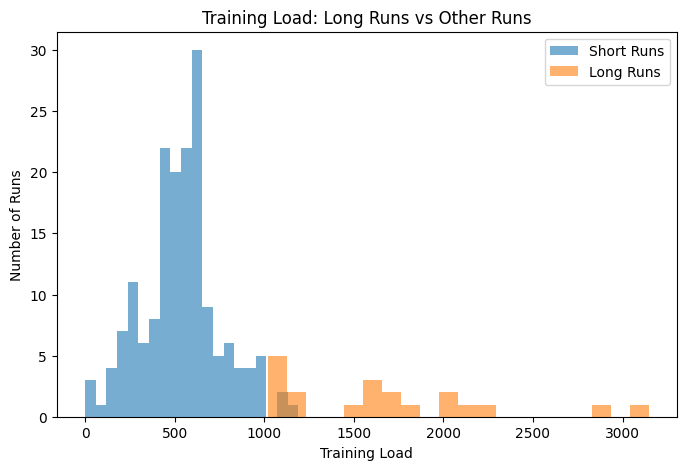

In [26]:
long_runs = df_runs[df_runs["distance_km"] >= 16]
short_runs = df_runs[df_runs["distance_km"] < 16]

plt.figure(figsize=(8,5))

plt.hist(short_runs["Training Load"].dropna(),
         bins=20,
         alpha=0.6,
         label="Short Runs")

plt.hist(long_runs["Training Load"].dropna(),
         bins=20,
         alpha=0.6,
         label="Long Runs")

plt.xlabel("Training Load")
plt.ylabel("Number of Runs")
plt.title("Training Load: Long Runs vs Other Runs")
plt.legend()

plt.show()

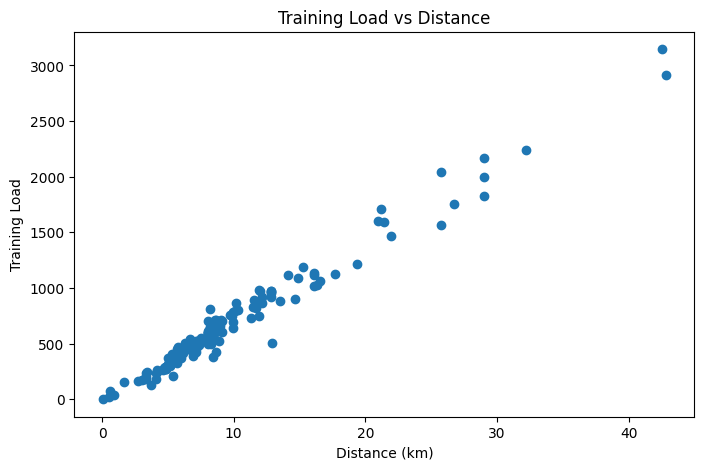

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    df_runs["distance_km"],
    df_runs["Training Load"]
)

plt.xlabel("Distance (km)")
plt.ylabel("Training Load")
plt.title("Training Load vs Distance")

plt.show()

In [28]:
print(
    df_runs.groupby(df_runs["distance_km"] >= 16)["Training Load"].describe()
)

             count         mean        std     min      25%     50%      75%  \
distance_km                                                                    
False        170.0   539.905882  216.91861     0.0   425.00   545.0   638.75   
True          20.0  1685.800000  603.95988  1019.0  1133.25  1598.0  2009.25   

                max  
distance_km          
False        1191.0  
True         3146.0  


In [29]:
df_runs[
    ["activity_date",
     "distance_km",
     "weekly_mileage",
     "monthly_mileage",
     "bimonthly_mileage",
     "avg_hr_28days",
     "avg_pace_mps_28days",
     "mean_cadence_28days",
     "longest_run_42days",
     "28d_run_count",
     "mean_trainingload_28days",
     "long_runs_count_42days",
     "avg_long_run_42days",
     "days_since_last_run"
     ]
].head(10)

,activity_date,distance_km,weekly_mileage,monthly_mileage,bimonthly_mileage,avg_hr_28days,avg_pace_mps_28days,mean_cadence_28days,longest_run_42days,28d_run_count,mean_trainingload_28days,long_runs_count_42days,avg_long_run_42days,days_since_last_run
267,2022-08-10 23:52:56,14.80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
266,2022-08-13 11:40:46,16.04,14.80,14.80,14.80,NaN,3.133000,NaN,14.80,1.0,NaN,0.0,NaN,2.491551
265,2022-08-16 23:24:06,8.38,30.84,30.84,30.84,NaN,2.928000,NaN,16.04,2.0,NaN,NaN,NaN,3.488426
264,2022-08-17 23:21:10,8.90,39.22,39.22,39.22,NaN,2.990000,NaN,16.04,3.0,NaN,NaN,NaN,0.997963
263,2022-08-20 11:38:32,26.60,48.12,48.12,48.12,155.000000,3.097750,NaN,16.04,4.0,NaN,1.0,16.04,2.512060
262,2022-08-23 23:26:19,1.11,43.88,74.72,74.72,149.000000,3.017800,NaN,26.60,5.0,NaN,NaN,NaN,3.491516
261,2022-08-23 23:41:00,6.99,44.99,75.83,75.83,148.333333,3.087833,NaN,26.60,6.0,NaN,NaN,NaN,0.010197
260,2022-08-25 00:10:00,10.31,43.60,82.82,82.82,151.000000,3.089714,NaN,26.60,7.0,NaN,NaN,NaN,1.020139
259,2022-08-27 11:17:24,33.53,53.91,93.13,93.13,154.400000,3.107875,NaN,26.60,8.0,NaN,2.0,21.32,2.463472
258,2022-08-30 23:20:52,8.46,78.54,126.66,126.66,154.666667,3.084667,NaN,33.53,9.0,NaN,NaN,NaN,3.502407


In [30]:
model_data = df_runs.dropna(
    subset=[
        "avg_hr_28days",
        "mean_cadence_28days"
    ]
)

In [31]:
feature_cols = [
    "weekly_mileage",
    "monthly_mileage",
    "bimonthly_mileage",
    "longest_run_42days",
    "avg_hr_28days",
    "mean_cadence_28days",
    "mean_trainingload_28days",
    "28d_run_count",

    "long_runs_count_42days",
    "avg_long_run_42days",
    "days_since_last_run"

]

target = "avg_speed_MS"

model_data = (
    df_runs[
        ["activity_date"] + feature_cols + [target]
    ]
    .dropna()
    .sort_values("activity_date")
)

In [32]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Make sure data is sorted chronologically
model_data = model_data.sort_values("activity_date")

X = model_data[feature_cols]
y = model_data[target]

tscv = TimeSeriesSplit(n_splits=5)

results = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model = RandomForestRegressor(
        random_state=42,
        n_estimators=200
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Fold": fold,
        "Train R²": model.score(X_train, y_train),
        "Test R²": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

cv_results = pd.DataFrame(results)

cv_results

,Fold,Train R²,Test R²,RMSE
0,1,0.812227,0.324240,0.245956
1,2,0.877159,-8.721490,0.442192
2,3,0.822795,-0.409151,0.162213
3,4,0.838391,-2.297425,0.221931
4,5,0.821694,-0.046903,0.230446


In [33]:
print(cv_results)

print("\nAverage Performance")
print("--------------------")
print(f"Train R²: {cv_results['Train R²'].mean():.3f}")
print(f"Test R² : {cv_results['Test R²'].mean():.3f}")
print(f"RMSE    : {cv_results['RMSE'].mean():.3f}")

   Fold  Train R²   Test R²      RMSE
0     1  0.812227  0.324240  0.245956
1     2  0.877159 -8.721490  0.442192
2     3  0.822795 -0.409151  0.162213
3     4  0.838391 -2.297425  0.221931
4     5  0.821694 -0.046903  0.230446

Average Performance
--------------------
Train R²: 0.834
Test R² : -2.230
RMSE    : 0.261


## Test on every run

XGBoost

Linear Regression

Random Forest


In [34]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {
        "model": model,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "RMSE": rmse
    }

In [35]:
results = pd.DataFrame({
    "Linear Regression": evaluate_model(LinearRegression(), X_train, X_test, y_train, y_test),
    "Random Forest": evaluate_model(RandomForestRegressor(random_state=42), X_train, X_test, y_train, y_test),
    "XGBoost": evaluate_model(XGBRegressor(random_state=42), X_train, X_test, y_train, y_test)
}).T
results

,model,Train R²,Test R²,RMSE
Linear Regression,LinearRegression(),0.774106,-0.857685,0.306974
Random Forest,"(DecisionTreeRegressor(max_features=1.0, rando...",0.829286,-0.082604,0.234342
XGBoost,"XGBRegressor(base_score=None, booster=None, ca...",0.999992,0.157136,0.206773


In [36]:
lr_results = evaluate_model(
    LinearRegression(),
    X_train, X_test, y_train, y_test
)

lr_model = lr_results["model"]

In [37]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coef_df.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
5,mean_cadence_28days,0.097608
8,long_runs_count_42days,0.053569
9,avg_long_run_42days,0.015253
10,days_since_last_run,0.012325
3,longest_run_42days,0.011200
0,weekly_mileage,0.007344
7,28d_run_count,0.005445
6,mean_trainingload_28days,-0.000298
2,bimonthly_mileage,-0.000946
1,monthly_mileage,-0.001328


In [38]:
corr = X.corr()

corr

,weekly_mileage,monthly_mileage,bimonthly_mileage,longest_run_42days,avg_hr_28days,mean_cadence_28days,mean_trainingload_28days,28d_run_count,long_runs_count_42days,avg_long_run_42days,days_since_last_run
weekly_mileage,1.000000,0.742005,0.733053,0.666647,0.078755,0.230054,0.639652,0.527438,0.692620,-0.232372,-0.264730
monthly_mileage,0.742005,1.000000,0.955350,0.865838,0.079820,0.453298,0.787327,0.804005,0.933374,-0.213838,-0.191740
bimonthly_mileage,0.733053,0.955350,1.000000,0.810411,0.012581,0.433695,0.793151,0.722882,0.910721,-0.183230,-0.209554
longest_run_42days,0.666647,0.865838,0.810411,1.000000,0.032973,0.318002,0.632368,0.733931,0.831806,-0.250520,-0.397482
avg_hr_28days,0.078755,0.079820,0.012581,0.032973,1.000000,0.530937,0.014624,0.095446,-0.022533,0.488493,0.219980
mean_cadence_28days,0.230054,0.453298,0.433695,0.318002,0.530937,1.000000,0.310776,0.415247,0.239387,0.449296,0.236888
mean_trainingload_28days,0.639652,0.787327,0.793151,0.632368,0.014624,0.310776,1.000000,0.298818,0.809585,0.038276,0.057011
28d_run_count,0.527438,0.804005,0.722882,0.733931,0.095446,0.415247,0.298818,1.000000,0.681126,-0.344720,-0.359988
long_runs_count_42days,0.692620,0.933374,0.910721,0.831806,-0.022533,0.239387,0.809585,0.681126,1.000000,-0.338115,-0.330758
avg_long_run_42days,-0.232372,-0.213838,-0.183230,-0.250520,0.488493,0.449296,0.038276,-0.344720,-0.338115,1.000000,0.498166


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [40]:
df_runs.corr(numeric_only=True)["avg_speed_MS"].sort_values()

,avg_speed_MS
Max Grade,-0.211659
Dirt Distance,-0.153258
Elevation High,-0.084533
days_since_last_run,-0.060227
elapsed_time_sec,-0.052134
elevation_gain,-0.027768
moving_time_sec,-0.018994
elevation_loss,-0.016571
max_cadence,-0.001630
Elevation Low,0.001556


In [41]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Mean R²:", scores.mean())
print("Std:", scores.std())

[-0.15354376 -0.0118619  -2.98046942 -1.97281159 -0.46147143]
Mean R²: -1.1160316219273476
Std: 1.1648367195393439


In [42]:
# tough_runs = df_runs[df_runs["avg_hr"] > 160 & (df_runs['distance_km'] >= 8)]
# tough_runs.head()